# Classical Forecasting Models

> **AUTHORITATIVE FAIR RESULTS + HISTORICAL STATIC-PROTOCOL CONTEXT**  
> This notebook is the single source of truth for Bitcoin ARIMA, Simple Exponential Smoothing, and Holt-Winters. It retains the original static multi-step forecasts unchanged for pedagogical comparison and adds the authoritative fair rolling one-step results generated by the shared audited implementation in `src/bitcoin_advanced_models.py`.


## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape, forecast_metric_row as evaluate_forecast
from src.bitcoin_advanced_models import (
    rolling_arima_log_return_forecast,
    rolling_holt_winters_forecast,
    rolling_simple_exp_smoothing_forecast,
)


E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"

df_raw = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(df_raw)
df_daily.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00+00:00,4.58,5.00,4.58,5.00,21.602000
2012-01-02 00:00:00+00:00,5.00,5.00,5.00,5.00,19.048000
2012-01-03 00:00:00+00:00,5.00,5.32,5.00,5.29,88.037281
2012-01-04 00:00:00+00:00,5.29,5.57,4.93,5.57,107.233260
2012-01-05 00:00:00+00:00,5.57,6.65,5.57,6.65,94.801829


## 3. Train-Test Split

In [3]:
target = df_daily["Close"].dropna().asfreq("D")
split_idx = int(len(target) * 0.8)

train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

train.shape, test.shape

((4241,), (1061,))

## 4. Naive Forecast

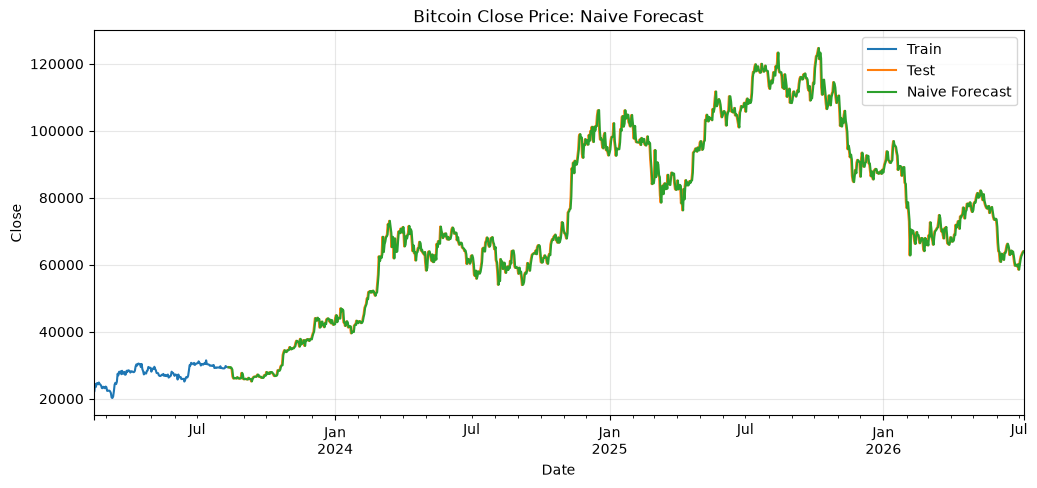

In [4]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
naive_forecast.plot(ax=ax, label="Naive Forecast")
ax.set_title("Bitcoin Close Price: Naive Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Moving Average Forecast

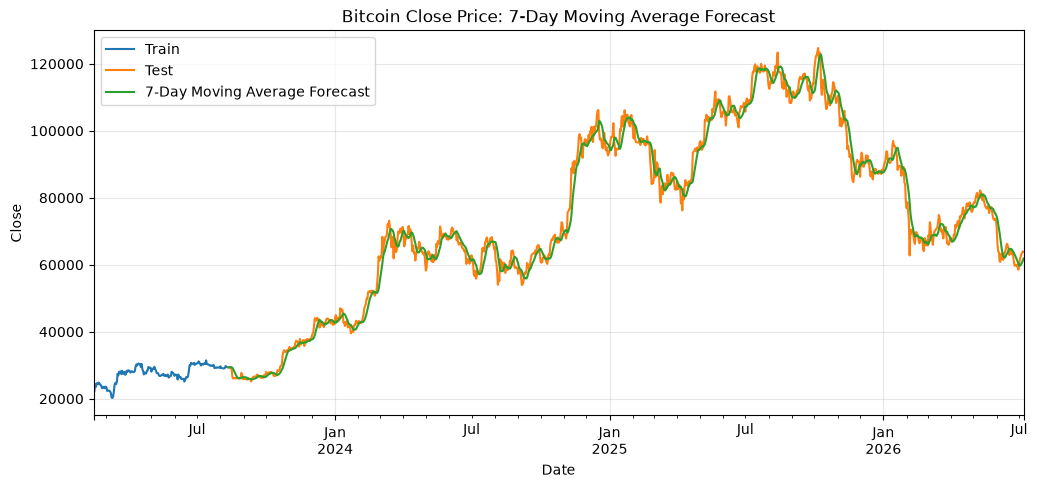

In [5]:
moving_average_forecast = (
    target.shift(1)
    .rolling(window=7)
    .mean()
    .reindex(test.index)
    .rename("7-Day Moving Average")
)

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
moving_average_forecast.plot(ax=ax, label="7-Day Moving Average Forecast")
ax.set_title("Bitcoin Close Price: 7-Day Moving Average Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 6. Exponential Smoothing — Original Static Multi-Step Protocol

The original Simple Exponential Smoothing and Holt-Winters implementations below fit once on the training set and forecast the entire 1,061-day test horizon without incorporating newly observed test values. Their code and historical outputs are retained unchanged to demonstrate the protocol effect.


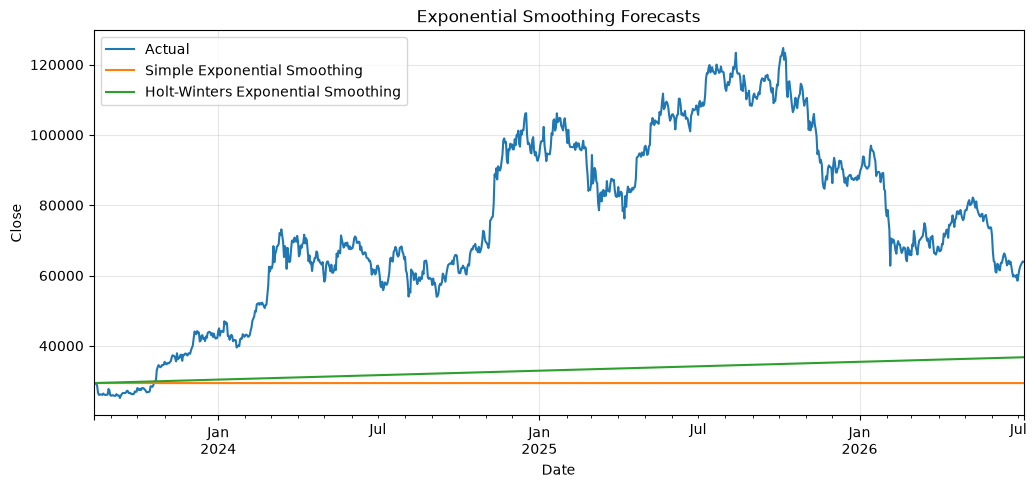

In [6]:
simple_exp_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated",
).fit(optimized=True)
simple_exp_forecast = simple_exp_model.forecast(len(test)).rename("Simple Exponential Smoothing")
simple_exp_forecast.index = test.index

holt_winters_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated",
).fit(optimized=True)
holt_winters_forecast = holt_winters_model.forecast(len(test)).rename("Holt-Winters")
holt_winters_forecast.index = test.index

fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual")
simple_exp_forecast.plot(ax=ax, label="Simple Exponential Smoothing")
holt_winters_forecast.plot(ax=ax, label="Holt-Winters Exponential Smoothing")
ax.set_title("Exponential Smoothing Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 6.1 Simple Exponential Smoothing — Authoritative Fair Rolling One-Step

For every test date, the shared audited implementation refits on the latest 128 prices ending strictly before that date. The resulting vector must match the frozen authoritative CSV exactly.


In [7]:
simple_exp_rolling_forecast = rolling_simple_exp_smoothing_forecast(target, test.index, context_length=128)
simple_exp_saved = pd.read_csv(PROJECT_ROOT / "results" / "simple_exp_smoothing_forecast.csv", parse_dates=["Timestamp"]).set_index("Timestamp")["Simple_Exp_Smoothing"]
simple_exp_saved.index = pd.to_datetime(simple_exp_saved.index, utc=True)
assert simple_exp_rolling_forecast.index.equals(test.index)
assert np.allclose(simple_exp_rolling_forecast, simple_exp_saved.reindex(test.index), rtol=1e-12, atol=1e-12)
pd.DataFrame([evaluate_forecast(test, simple_exp_rolling_forecast)], index=["Simple Exponential Smoothing Rolling One-Step"])


,MAE,RMSE,MAPE,sMAPE
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871


### 6.2 Holt-Winters — Authoritative Fair Rolling One-Step

The shared implementation refits the additive-trend, non-seasonal model for every test date on the latest 128 strictly prior prices. No weekly seasonal component is used because the audited seasonality diagnostics did not support one.


In [8]:
holt_winters_rolling_forecast = rolling_holt_winters_forecast(target, test.index, context_length=128)
holt_winters_saved = pd.read_csv(PROJECT_ROOT / "results" / "holt_winters_forecast.csv", parse_dates=["Timestamp"]).set_index("Timestamp")["Holt_Winters"]
holt_winters_saved.index = pd.to_datetime(holt_winters_saved.index, utc=True)
assert holt_winters_rolling_forecast.index.equals(test.index)
assert np.allclose(holt_winters_rolling_forecast, holt_winters_saved.reindex(test.index), rtol=1e-12, atol=1e-12)
pd.DataFrame([evaluate_forecast(test, holt_winters_rolling_forecast)], index=["Holt-Winters Rolling One-Step"])


,MAE,RMSE,MAPE,sMAPE
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.76364,1.763424


## 7. ARIMA — Original Static Multi-Step Protocol

The original ARIMA(1,1,1) implementation below fits once and forecasts the complete test horizon. Its code and historical output are retained unchanged.


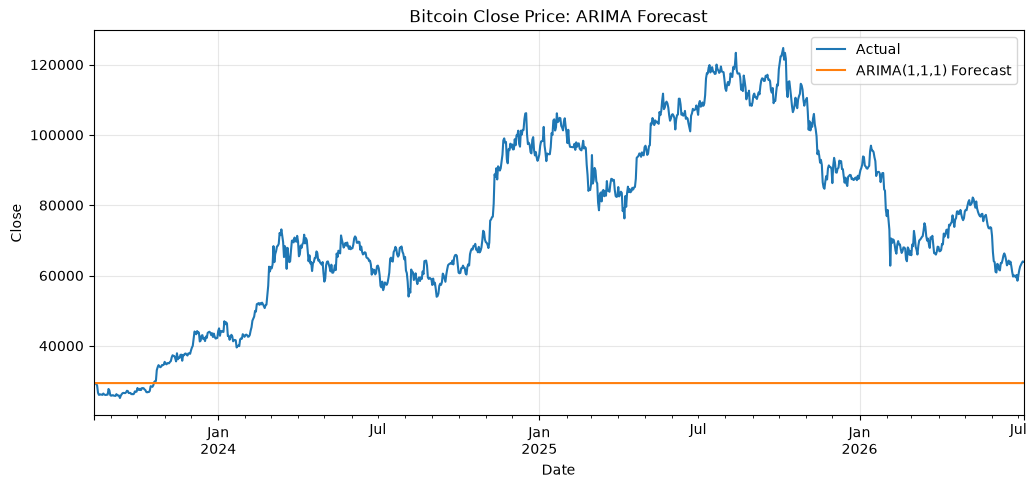

In [9]:
arima_order = (1, 1, 1)
arima_model = ARIMA(train, order=arima_order).fit()
arima_forecast = arima_model.forecast(steps=len(test)).rename("ARIMA(1,1,1)")
arima_forecast.index = test.index

fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual")
arima_forecast.plot(ax=ax, label="ARIMA(1,1,1) Forecast")
ax.set_title("Bitcoin Close Price: ARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 7.1 ARIMA — Authoritative Fair Rolling One-Step

The shared audited implementation forecasts one log return at a time from a 128-day context and appends each observed return only after its forecast has been made.


In [10]:
arima_rolling_forecast = rolling_arima_log_return_forecast(target, test.index, context_length=128, order=(1, 0, 1))
arima_saved = pd.read_csv(PROJECT_ROOT / "results" / "arima_rolling_forecast.csv", parse_dates=["Timestamp"]).set_index("Timestamp")["ARIMA_Rolling"]
arima_saved.index = pd.to_datetime(arima_saved.index, utc=True)
assert arima_rolling_forecast.index.equals(test.index)
assert np.allclose(arima_rolling_forecast, arima_saved.reindex(test.index), rtol=1e-12, atol=1e-12)
pd.DataFrame([evaluate_forecast(test, arima_rolling_forecast)], index=["ARIMA Rolling One-Step"])


,MAE,RMSE,MAPE,sMAPE
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209


### 7.2 Static-versus-Fair Protocol Comparison

The table directly compares each retained historical static forecast with its authoritative rolling one-step counterpart. The apparent 25–28× failure largely disappears when each model is allowed to use information that would genuinely be available before every forecast date.


In [11]:
protocol_comparison = pd.DataFrame(
    [
        {"Model": "Simple Exponential Smoothing", "Historical Static RMSE": rmse(test, simple_exp_forecast), "Fair Rolling RMSE": rmse(test, simple_exp_rolling_forecast)},
        {"Model": "Holt-Winters", "Historical Static RMSE": rmse(test, holt_winters_forecast), "Fair Rolling RMSE": rmse(test, holt_winters_rolling_forecast)},
        {"Model": "ARIMA", "Historical Static RMSE": rmse(test, arima_forecast), "Fair Rolling RMSE": rmse(test, arima_rolling_forecast)},
    ]
).set_index("Model")
protocol_comparison["Static / Fair RMSE Ratio"] = protocol_comparison["Historical Static RMSE"] / protocol_comparison["Fair Rolling RMSE"]
protocol_comparison


,Historical Static RMSE,Fair Rolling RMSE,Static / Fair RMSE Ratio
Model,,,
Simple Exponential Smoothing,52421.328707,1855.731424,28.248338
Holt-Winters,48571.096828,1871.702185,25.950227
ARIMA,52421.667992,1866.302859,28.088511


## 8. Evaluation Metrics — Fair Rolling One-Step Headline Results


In [12]:
forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Simple Exponential Smoothing Rolling One-Step": simple_exp_rolling_forecast,
    "Holt-Winters Rolling One-Step": holt_winters_rolling_forecast,
    "ARIMA Rolling One-Step": arima_rolling_forecast,
}

metrics_table = pd.DataFrame(
    [evaluate_forecast(test, forecast) for forecast in forecasts.values()],
    index=forecasts.keys(),
)

metrics_table

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209


## 9. Model Comparison — Fair Rolling One-Step Forecasts


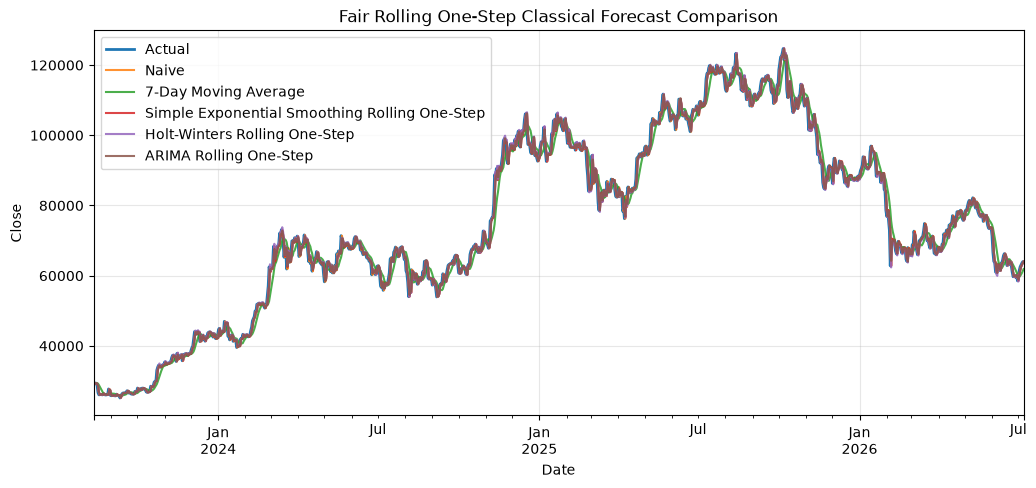

,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Fair Rolling One-Step Classical Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

metrics_table.sort_values("RMSE")

## 10. Forecast Diagnostics — Fair Rolling One-Step Forecasts


First 10 forecast diagnostics:
                            y_test    Naive  7-Day Moving Average  Simple Exponential Smoothing Rolling One-Step  Holt-Winters Rolling One-Step  ARIMA Rolling One-Step
Timestamp                                                                                                                                                              
2023-08-12 00:00:00+00:00  29415.0  29398.0          29346.000000                                   29402.736072                   29418.077201            29411.966602
2023-08-13 00:00:00+00:00  29284.0  29415.0          29398.285714                                   29413.634578                   29427.341377            29422.050848
2023-08-14 00:00:00+00:00  29408.0  29284.0          29432.857143                                   29298.577428                   29305.240416            29316.287272
2023-08-15 00:00:00+00:00  29172.0  29408.0          29465.285714                                   29394.207690                 

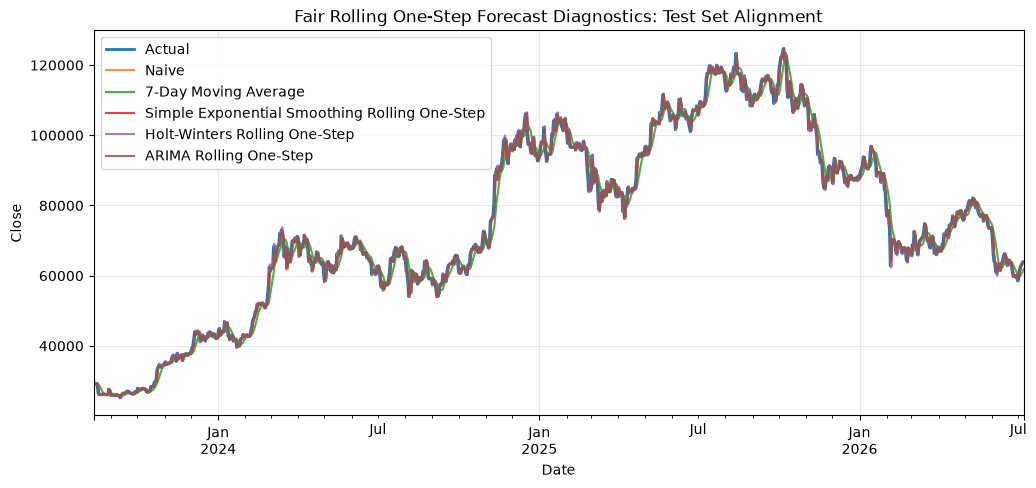

In [14]:
diagnostics = pd.DataFrame(
    {
        "y_test": y_test,
        "Naive": naive_forecast,
        "7-Day Moving Average": moving_average_forecast,
        "Simple Exponential Smoothing Rolling One-Step": simple_exp_rolling_forecast,
        "Holt-Winters Rolling One-Step": holt_winters_rolling_forecast,
        "ARIMA Rolling One-Step": arima_rolling_forecast,
    }
)

print("First 10 forecast diagnostics:")
print(diagnostics.head(10).to_string())

print("Naive forecast equals one-step lagged actuals:")
print(naive_forecast.equals(target.shift(1).reindex(y_test.index)))

print("Rolling ARIMA forecast index aligns with y_test:")
print(arima_rolling_forecast.index.equals(y_test.index))

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)

for model_name, forecast in forecasts.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.85)

ax.set_title("Fair Rolling One-Step Forecast Diagnostics: Test Set Alignment")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The naive forecast is implemented as true one-step persistence using the previous observed close for each test timestamp. The diagnostic check should return `True` when `naive_forecast` equals `target.shift(1).reindex(y_test.index)`. The fair rolling ARIMA vector uses the exact test index, so its alignment check should also return `True`.


## 11. Key Findings

- The original static multi-step forecasts remain intact as historical evidence of an unfair information protocol.
- Under the authoritative rolling one-step protocol, Simple Exponential Smoothing achieves RMSE 1,855.73, ARIMA 1,866.30, and Holt-Winters 1,871.70.
- The static-to-fair RMSE ratios are approximately 28.2× for Simple Exponential Smoothing, 28.1× for ARIMA, and 26.0× for Holt-Winters.
- These fair classical results are comparable to the Naive baseline rather than meaningfully worse.
